# DATA-445 — Homework Assignment 1

**Instructions**

- This homework assignment is worth 94 points.
- Please submit a `.ipynb` file to Blackboard.
- Please strive for clarity and organization.
- **AI usage**:
  - AI use is strictly **prohibited** for conceptual exercises.
  - For applied (Python) exercises, you may use AI exclusively for **debugging**. Do not use AI to generate answers.
- **Due Date: September 11, 2026, by 11:59 PM.**

## Exercise 1

(4 points) What type of algorithm would you use to segment a company customers database into multiple groups?


I would use clustering to put customers into differents groups based on the things they have in common  

## Exercise 2

(4 points) Would you frame the problem of spam detection as a supervised learning problem or an unsupervised learning problem? Explain.

i would use supervise learniing because the model can learn from the email that are already marked as spam or not.  

## Exercise 3

(4 points) What is a test set, and why would you want to use it?

A test set is a group of data used to see if the models works well. It helps us know if the model can make good predictions with new data 

## Exercise 4

(4 points) You are training a classification model with 100 variables/features that achieves 95% accuracy in the training dataset. However, when you run it in the test dataset, you only get 60% accuracy. Which of the following options are valid approached to solve this problem?

- (a) Reduce the number of input variables/features
- (b) Add extra variables/features
- (c) Implement cross-validation during the training process
- (d) Select another algorithm
- (e) (a) and (c)
- (f) (a) and (d)
- (g) (b) and (c)
- (h) (b) and (d)
- (i) None of the above 

 (e) (a) and (c)

## Exercise 5

Consider the `Real_Estate.csv` data file posted on Blackboard (under the In-Class 3f assignment link). This file contains information related to 414 houses. The goal is to predict the house price of unit area. In **Python**, answer the following:

### (a) (3 points)

Using the pandas library, read the csv data file and create a data-frame called `house_price`.

In [1]:
import pandas as pd 

#reading the data file
house_price = pd.read_csv("Real_Estate.csv")
house_price.head()

,No,transaction_date,house_age,distance_to_the_nearest_MRT_station,number_of_convenience_stores,latitude,longitude,house_price_of_unit_area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


### (b) (3 points)

Drop the `No` and `transaction_date` columns.

In [2]:
house_price = house_price.drop(columns=["No", "transaction_date"], axis=1)
house_price.head()

,house_age,distance_to_the_nearest_MRT_station,number_of_convenience_stores,latitude,longitude,house_price_of_unit_area
0,32.0,84.87882,10,24.98298,121.54024,37.9
1,19.5,306.59470,9,24.98034,121.53951,42.2
2,13.3,561.98450,5,24.98746,121.54391,47.3
3,13.3,561.98450,5,24.98746,121.54391,54.8
4,5.0,390.56840,5,24.97937,121.54245,43.1


### (c) (4 points)

Split the data-frame into two data-frames: train (80%) and test (20%).

In [3]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(house_price, test_size=0.2, random_state=42)

### (d) (8 points)

Using the `house_price` data-frame, compute the correlation between each input variable and `house_price_of_unit_area`, and display the results as a heatmap. Which two variables are most correlated (in absolute value) with the target variable?

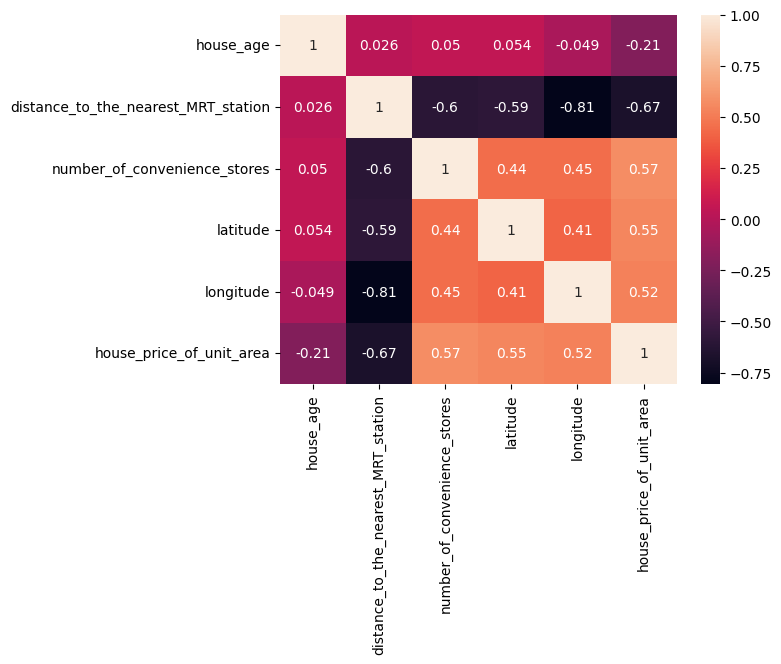

In [4]:
import seaborn as sns 
import matplotlib.pyplot as plt

correlation = house_price.corr()

sns.heatmap(correlation, annot=True)
plt.show()


In [5]:
correlation["house_price_of_unit_area"].sort_values()

distance_to_the_nearest_MRT_station   -0.673613
house_age                             -0.210567
longitude                              0.523287
latitude                               0.546307
number_of_convenience_stores           0.571005
house_price_of_unit_area               1.000000
Name: house_price_of_unit_area, dtype: float64

Which two variables are most correlated (in absolute value) with the target variable?

distance_to_the_nearest_MRT_station and  number_of_convenience_stores (0.571005)

### (e) (10 points)

Using the train data-frame, build a linear regression model in which: `house_age`, `distance_to_the_nearest_MRT_station`, `number_of_convenience_stores`, `latitude`, and `longitude` are the input variables, and `house_price_of_unit_area` is the target variable. After the model is built, predict the house price of unit area of the houses in the test data-frame. Report the MSE.

In [6]:
from sklearn.linear_model import LinearRegression

X= train [["house_age","distance_to_the_nearest_MRT_station","number_of_convenience_stores","latitude","longitude"]]
Y= train ["house_price_of_unit_area"]
model = LinearRegression()
model.fit(X,Y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
new_data = test[["house_age","distance_to_the_nearest_MRT_station","number_of_convenience_stores","latitude","longitude"]]
prediction = model.predict(new_data)
prediction

array([47.74180481, 41.95484652, 44.5399885 , 41.33697932, 30.28548   ,
       42.84474934, 45.98717123, 45.90599326, 24.78369465, 52.02068924,
       32.23880597, 34.77542016, 39.51392044, 24.90203898, 35.73984968,
       32.99552705, 41.96863217, 46.98662328, 31.50100311, 44.49258341,
        2.21362693, 33.64381059, 47.764103  , 43.56374399, 14.07301949,
       41.29883092, 14.73315281, 44.5399885 , 36.13972668, 37.76019401,
       11.66211419, 39.22848089, 37.83881729, 28.61334713, 45.93500741,
       31.52925298, 52.2101045 , 15.18188713, 46.84531477, 40.47464938,
       36.01694465, 40.58052131, 48.38869976, 39.8943259 , 42.00896517,
       48.22742934, 45.07252677, 23.5290158 , 49.9849698 , 48.13933326,
       47.74180481, 48.54209921, 40.94754085, 42.54642454, 36.38766353,
       15.15482781, 35.13348041, 36.39866246, 30.20430203, 45.90599326,
       33.69672647, 32.65567761, 15.15482781, 11.8739673 ,  8.74877596,
       33.67086991, 29.81801432, 45.24751413, 34.2425491 , 30.54

In [8]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(test["house_price_of_unit_area"], prediction)
mse

54.58094520086175

MSE = 54.5809

### (f) (10 points)

Using the train data-frame, build a linear regression model in which: `house_age`, `number_of_convenience_stores`, `latitude`, and `longitude` are the input variables, and `house_price_of_unit_area` is the target variable. After the model is built, predict the house price of unit area of the houses in the test data-frame. Report the MSE.

In [10]:
from sklearn.linear_model import LinearRegression

X= train [["house_age","number_of_convenience_stores","latitude","longitude"]]
Y= train ["house_price_of_unit_area"]
model = LinearRegression()
model.fit(X,Y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
new_data = test[["house_age","number_of_convenience_stores","latitude","longitude"]]
prediction = model.predict(new_data)
prediction

array([45.95000934, 40.13513523, 39.46464958, 35.41577258, 29.52042075,
       43.46038282, 46.29314966, 46.20968042, 20.37416134, 52.49084233,
       30.03679643, 34.04131239, 40.20821479, 20.46203692, 35.47168997,
       30.70292604, 42.31014236, 43.34526313, 31.39701939, 44.91379463,
       10.27035063, 32.03096843, 48.11272022, 42.58055207, 16.74430866,
       35.46753821, 17.12846744, 39.46464958, 33.3803881 , 38.28757125,
       14.93339377, 37.50007279, 36.88509657, 30.22795732, 46.3424597 ,
       27.31282634, 52.68560389, 17.5996783 , 48.62101654, 40.51448417,
       36.71710437, 39.54160942, 49.37147983, 38.52802882, 40.19078139,
       49.19760319, 46.52592689, 33.30560128, 48.11844681, 49.12395605,
       45.95000934, 49.34359628, 41.73187311, 42.48031315, 33.95982964,
       17.57185522, 33.09293234, 40.91746955, 29.43695151, 46.20968042,
       33.00161534, 30.50110742, 17.57185522, 14.96532252, 17.54899085,
       32.05879151, 31.13307085, 47.21206524, 31.43620728, 31.88

In [12]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(test["house_price_of_unit_area"], prediction)
mse

57.75527955240991

MSE = 57.7552

### (g) (5 points)

Using the results from parts (d) and (e), what model would you use? Explain.

I wouls use the model from part (e) because it had a lower MSE compare to part (f), it's predictions were more accurate. This make sense because we have 
distance_to_the_nearest_MRT_station in part (e) while part (f) does not.

### (h) (15 points)

Repeat steps (c) to (e) 100 times, and visualize the MSE of each of the models at each iteration. Which of the two model has better performance on the test datasets? Explain.

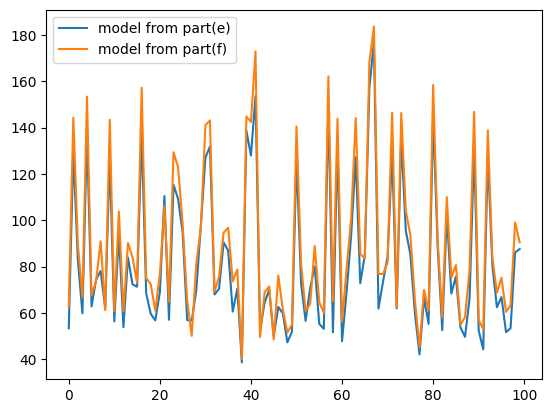

82.56120688668763
90.0318287961379


In [17]:
import numpy as np

mse_list_full = []
mse_list_reduce = []

for i in range(100):
    train, test = train_test_split(house_price, test_size=0.2)

    correlation = house_price.corr()
    correlation["house_price_of_unit_area"].sort_values()

    X= train [["house_age","distance_to_the_nearest_MRT_station","number_of_convenience_stores","latitude","longitude"]]
    Y= train ["house_price_of_unit_area"]
    model = LinearRegression()
    model.fit(X,Y)
    new_data = test[["house_age","distance_to_the_nearest_MRT_station","number_of_convenience_stores","latitude","longitude"]]
    prediction = model.predict(new_data)
    mse = mean_squared_error(test["house_price_of_unit_area"], prediction)
    mse_list_full.append(mse)


    X2= train [["house_age","number_of_convenience_stores","latitude","longitude"]]
    Y2= train ["house_price_of_unit_area"]
    model2 = LinearRegression()
    model2.fit(X2,Y2)
    new_data2 = test[["house_age","number_of_convenience_stores","latitude","longitude"]]
    prediction2 = model2.predict(new_data2)
    mse2 = mean_squared_error(test["house_price_of_unit_area"], prediction2)
    mse_list_reduce.append(mse2)


plt.plot(mse_list_full, label="model from part(e)")
plt.plot(mse_list_reduce, label="model from part(f)")
plt.legend()
plt.show()

print(np.mean(mse_list_full))
print(np.mean(mse_list_reduce))

    

the MSE from part(e) is lower than the MSE from part (f), so part(e) perform better because it has distance_to_the_nearest_MRT_station

### (i) (8 points) 
Using scikit-learn's `cross_val_score`, perform 10-fold cross-validation on the full model from Exercise 5, part (d) (using the entire `house_price` data-frame). Report the average MSE across the 10 folds.

In [22]:

from sklearn.model_selection import cross_val_score

X= house_price [["house_age","distance_to_the_nearest_MRT_station","number_of_convenience_stores","latitude","longitude"]]
Y= house_price ["house_price_of_unit_area"]

model = LinearRegression()
scores = cross_val_score(model, X, Y, cv=10, scoring="neg_mean_squared_error")

mse_scores = -scores
print(mse_scores.mean())

81.01108645099032


## Exercise 6

(6 points) Explain the bias-variance tradeoff, and describe how it relates to a model's ability to generalize to new/unseen data.

Bias-variance tradeoff means finding a balance between a model being too simple or too complicated. 
A model that is too simple may not learn anough and a model that is too complicated may memorize the trainig data. A good balance helps the model work well on new data

## Exercise 7

(6 points) The "curse of dimensionality" refers to the difficulties that arise when working with data that has a very large number of features. Explain why having too many features can hurt the performance of a machine learning model, and describe one strategy to mitigate this problem.

The curse of dimensionality means that having too many features can make a machine learning model confused and less accurate. It can also make the model slower and more likely to overfit.
One way to fix this is to remove features that are not important and keep only the features that can help the model